# 06 · Değerlendirme (Aşama 7)
Modeli hiç kullanılmamış **test** bölümünde ölçmek, hatalarını incelemek ve kestirme öğrenme şüphesini sınamak.

## 1. Test bölümünde ölçüm

Model şimdiye kadar hep **val** ile ölçüldü, ama val eğitim sırasında her epoch kullanıldı ve `best.pt` ona göre seçildi. `test` bölümüne ise hiç dokunulmadı: ne eğitimde, ne model seçiminde.

| Bölüm | Eğitimde | Model seçiminde |
|---|---|---|
| train | ✅ | |
| val | ❌ | ✅ |
| **test** | ❌ | ❌ |

**Sonuç: test mAP50 = 0.800, val = 0.789.** Test val'den kötü değil → model ezberlememiş, öğrendiği genel geçer.
*(Not: bu ölçüm yerel paketteki 72 fotoğrafla yapıldı; tam test bölümünde 2.798 fotoğraf var.)*

In [7]:
from ultralytics import YOLO                            # YOLO sınıfını al

model = YOLO("../models/iha_yolo11n.pt")                # kendi eğittiğimiz model

sonuc = model.val(                                      # val() = ölçüm yap (eğitim değil)
    data="../data/kucuk_paket/yerel.yaml",              # hangi veri: yollar + sınıflar
    split="test",                                       # hangi bölüm: val değil TEST
    device="mps",                                       # Mac'in GPU'su ("cpu" da olur, daha yavaş)
)

print("mAP50   :", round(sonuc.box.map50, 3))           # sonuçtan mAP50'yi al, 3 basamağa yuvarla
print("mAP50-95:", round(sonuc.box.map, 3))             # mAP50-95

Ultralytics 8.4.160 🚀 Python-3.13.0 torch-2.14.0 MPS (Apple M2)
YOLO11n summary (fused): 100 layers, 2,583,517 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.0 ms, read: 798.3±529.0 MB/s, size: 382.0 KB)
val: Scanning /Users/eeren/Developer/iha-goruntu-isleme/data/kucuk_paket/labels/test.cache... 72 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72 23.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.8it/s 2.8s0.8s
                   all         72        304      0.924      0.757        0.8      0.543
                person         36        112       0.91      0.902      0.947      0.658
                   car         21         87       0.92      0.805      0.929      0.703
               bicycle          4         55       0.68      0.782      0.765      0.391
         other_vehicle          1          1          1          0          0          0
                 drone   

## 2. Hazırlık
Fotoğrafı ve etiket kutularını piksel cinsinden döndüren yardımcı fonksiyon. `yolo_kutu`'nun yaptığı dönüşümün (oran → piksel, merkez → köşe) tüm etiketler için toplu hali.

In [8]:
import cv2                                                # OpenCV
import matplotlib.pyplot as plt                           # göstermek için

def oku(ad, bolum="train"):                               # fotoğrafı + kutularını döndürür
    foto = cv2.imread(f"../data/kucuk_paket/images/{bolum}/{ad}.png")   # fotoğrafı oku
    yukseklik, genislik = foto.shape[0], foto.shape[1]     # boyutları al

    kutular = []                                           # kutuları biriktireceğiz
    with open(f"../data/kucuk_paket/labels/{bolum}/{ad}.txt") as dosya:
        etiketler = dosya.read().splitlines()              # etiket satırları

    for satir in etiketler:                                # her nesne için:
        parcalar = satir.split()                           #   satırı böl
        numara = int(parcalar[0])                          #   sınıf numarası
        mx = float(parcalar[1]) * genislik                 #   merkez x (piksel)
        my = float(parcalar[2]) * yukseklik                #   merkez y
        g  = float(parcalar[3]) * genislik                 #   kutu genişliği
        y  = float(parcalar[4]) * yukseklik                #   kutu yüksekliği
        x1 = round(mx - g / 2)                             #   sol kenar
        y1 = round(my - y / 2)                             #   üst kenar
        x2 = round(mx + g / 2)                             #   sağ kenar
        y2 = round(my + y / 2)                             #   alt kenar
        kutular.append((numara, x1, y1, x2, y2))           #   listeye ekle

    return foto, kutular                                   # iki şey birden döndürür


iha, kutular = oku("01_uav2uav__430__864a7aebf1")          # İHA fotoğrafını oku
print(kutular)

[(4, 260, 308, 320, 343), (4, 575, 146, 640, 196)]


### 2.1 İHA'yı kes
Kutu koordinatlarıyla dilimleme: `iha[y1:y2, x1:x2]`. `.copy()` şart, yoksa parça asıl fotoğrafa açılan bir pencere olur.

parçanın boyutu: (35, 60, 3)


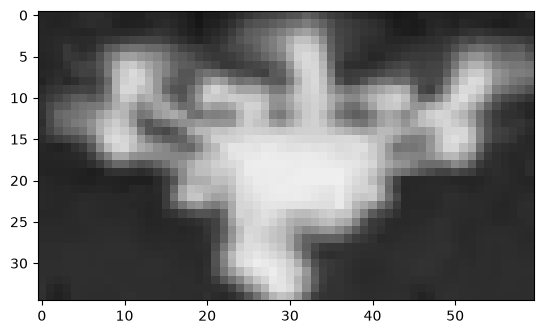

In [9]:
numara, x1, y1, x2, y2 = kutular[0]          # ilk kutuyu 5 ayrı isme dağıt

parca = iha[y1:y2, x1:x2].copy()             # kutu bölgesini kes
                                             # DİKKAT: [satır, sütun] = [y, x] sırası!
                                             # .copy() → bağımsız bir parça olsun

print("parçanın boyutu:", parca.shape)       # (yükseklik, genişlik, 3)

plt.imshow(cv2.cvtColor(parca, cv2.COLOR_BGR2RGB))   # BGR → RGB çevirip göster
plt.show()


## 3. Kestirme öğrenme testi

**Şüphe:** Her sınıf tek bir kaynaktan geliyor (İHA'lar hep `uav2uav`, gökyüzü arka planlı). Model **nesneyi** mi, yoksa **arka planı** mı öğrendi?

**Yöntem:** Aynı İHA parçasını farklı arka planlara yapıştırıp modele sormak. Nesne birebir aynı, değişen tek şey arka plan.

### 3.1 Kontrol: kendi gökyüzüne yapıştır
Yapıştırma işleminin kendisi sorun çıkarıyor mu? → **Hayır, 0.89 güvenle tanındı.**

bulunan kutu sayısı: 3
    drone 0.89
    drone 0.86
    drone 0.84


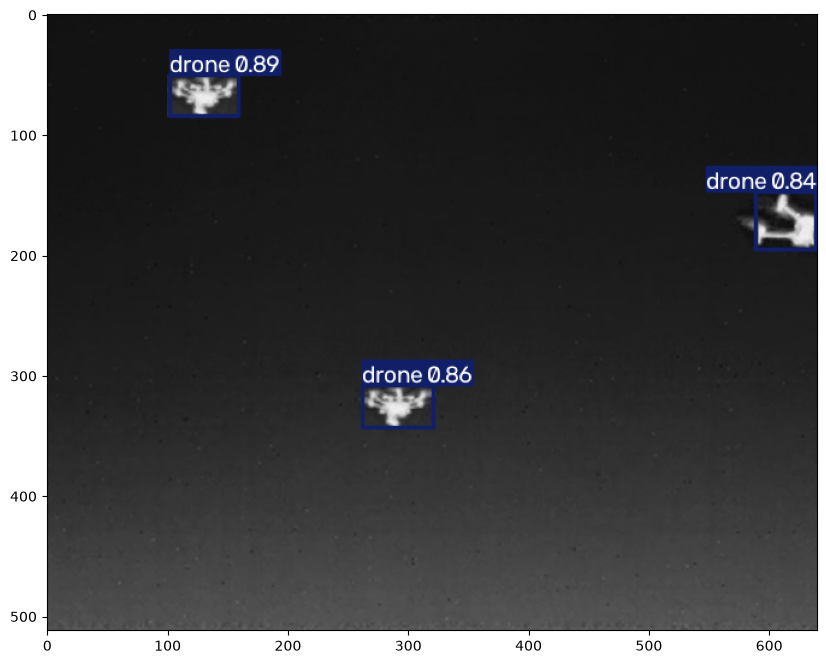

In [ ]:
from ultralytics import YOLO                       # (zaten yüklüyse tekrar zararsız)
model = YOLO("../models/iha_yolo11n.pt")

ph = parca.shape[0]                                # parçanın yüksekliği (35)
pw = parca.shape[1]                                # parçanın genişliği  (60)

kopya = iha.copy()                                 # orijinali bozmamak için kopya
kopya[50:50+ph, 100:100+pw] = parca                # parçayı (y=50, x=100) noktasına yapıştır
                                                   # sağ taraf parçanın kendisi, sol taraf hedef bölge

sonuc = model(kopya, verbose=False)[0]             # modele sor (dosya yolu değil, resmin kendisi)

print("bulunan kutu sayısı:", len(sonuc.boxes))
for kutu in sonuc.boxes:
    print("   ", model.names[int(kutu.cls)], round(float(kutu.conf), 2))

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(sonuc.plot(), cv2.COLOR_BGR2RGB))
plt.show()

### 3.2 Asfalta yapıştır
Aynı parça, otopark fotoğrafının asfaltında. → **23 kutu bulundu, hepsi `car`, hiç `drone` yok.**

bulunan kutu sayısı: 23


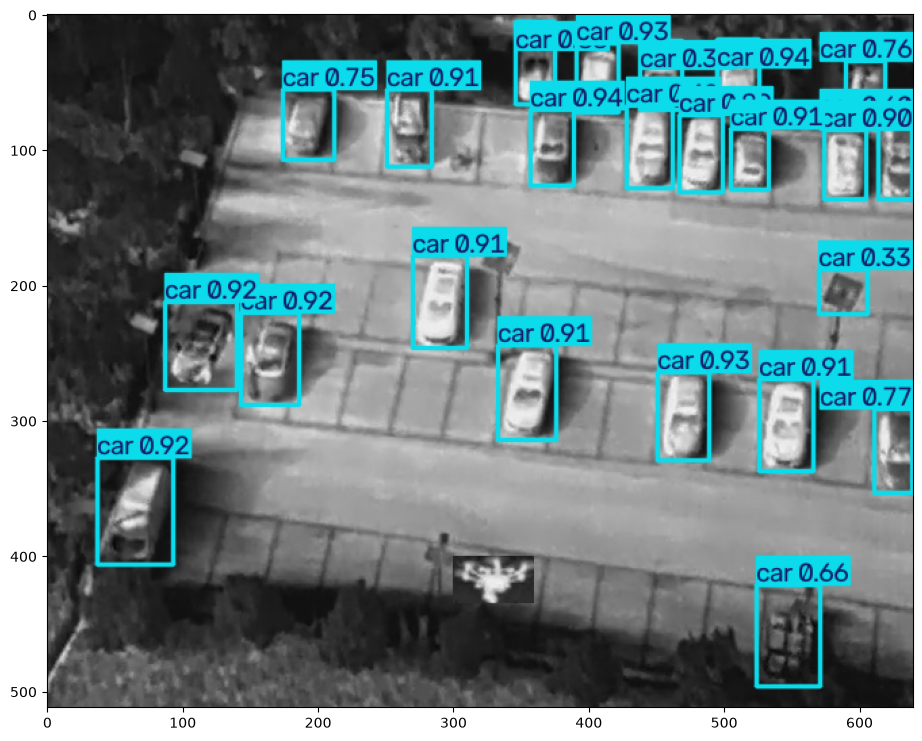

In [15]:
otopark, _ = oku("02_hituav__0_100_50_0_08164__c5427da128")

kopya2 = otopark.copy()
kopya2[400:400+ph, 300:300+pw] = parca

sonuc2 = model(kopya2, verbose=False)[0]

print("bulunan kutu sayısı:", len(sonuc2.boxes))
for kutu in sonuc2.boxes:
    if model.names[int(kutu.cls)] == "drone":
        print("   DRONE bulundu:", round(float(kutu.conf), 2))

plt.figure(figsize=(12, 9))
plt.imshow(cv2.cvtColor(sonuc2.plot(), cv2.COLOR_BGR2RGB))
plt.show()

### (hazırlık tekrarı)
Kernel yeniden başladığında gereken hafif hücre: import'lar, `oku` fonksiyonu, iki fotoğraf.

In [4]:
import cv2                                                     # OpenCV
import numpy as np                                             # sayı işlemleri
import matplotlib.pyplot as plt                                # gösterim

def oku(ad, bolum="train"):                                    # fotoğrafı + kutularını döndürür
    foto = cv2.imread(f"../data/kucuk_paket/images/{bolum}/{ad}.png")
    yukseklik, genislik = foto.shape[0], foto.shape[1]

    kutular = []
    with open(f"../data/kucuk_paket/labels/{bolum}/{ad}.txt") as dosya:
        etiketler = dosya.read().splitlines()

    for satir in etiketler:
        parcalar = satir.split()
        numara = int(parcalar[0])
        mx = float(parcalar[1]) * genislik
        my = float(parcalar[2]) * yukseklik
        g  = float(parcalar[3]) * genislik
        y  = float(parcalar[4]) * yukseklik
        kutular.append((numara,
                        round(mx - g / 2), round(my - y / 2),
                        round(mx + g / 2), round(my + y / 2)))

    return foto, kutular


iha, kutular = oku("01_uav2uav__430__864a7aebf1")              # İHA fotoğrafı
otopark, _ = oku("02_hituav__0_100_50_0_08164__c5427da128")    # otopark fotoğrafı

print("iha:", iha.shape, "| otopark:", otopark.shape)

iha: (512, 640, 3) | otopark: (512, 640, 3)


## 4. Klasik yöntem: sadece OpenCV ile tespit

YOLO'suz, eğitimsiz yaklaşım. Zincir: **gri tonlama → eşikleme → morfoloji → kontur → boyut süzgeci**.

### 4.1 Eşikleme (Otsu)
Her piksele tek soru: "eşikten parlak mısın?" Parlaksa 255, değilse 0. Otsu eşik değerini görüntünün parlaklık dağılımından kendisi buluyor (burada 47).

Otsu'nun bulduğu eşik: 47.0


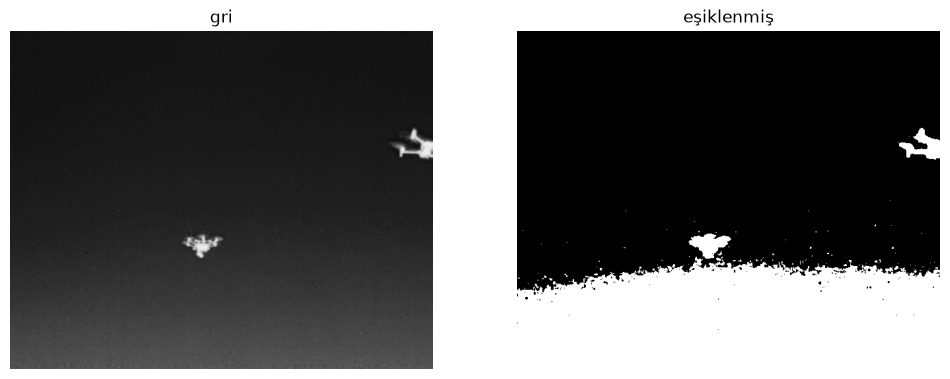

In [16]:
gri = cv2.cvtColor(iha, cv2.COLOR_BGR2GRAY)      # renkli → gri (tek kanal)

esik_deger, esik = cv2.threshold(                # eşikleme, İKİ değer döndürür
    gri,                                         #   girdi: gri görüntü
    0,                                           #   eşik değeri (Otsu kullanınca önemsiz)
    255,                                         #   eşiği geçenler bu değeri alsın
    cv2.THRESH_BINARY + cv2.THRESH_OTSU          #   ikili eşikleme + eşiği Otsu bulsun
)

print("Otsu'nun bulduğu eşik:", esik_deger)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)                             # 1 satır, 2 sütun, 1. hücre
plt.imshow(gri, cmap="gray", vmin=0, vmax=255)
plt.title("gri")
plt.axis("off")

plt.subplot(1, 2, 2)                             # 2. hücre
plt.imshow(esik, cmap="gray", vmin=0, vmax=255)
plt.title("eşiklenmiş")
plt.axis("off")

plt.show()

### 4.2 Morfoloji — açma (opening)
Aşındırma + genişletme. Küçük lekeler silinir, büyükler yerinde kalır. Elekten geçirmek gibi: küçük taneler düşer, iriler kalır.

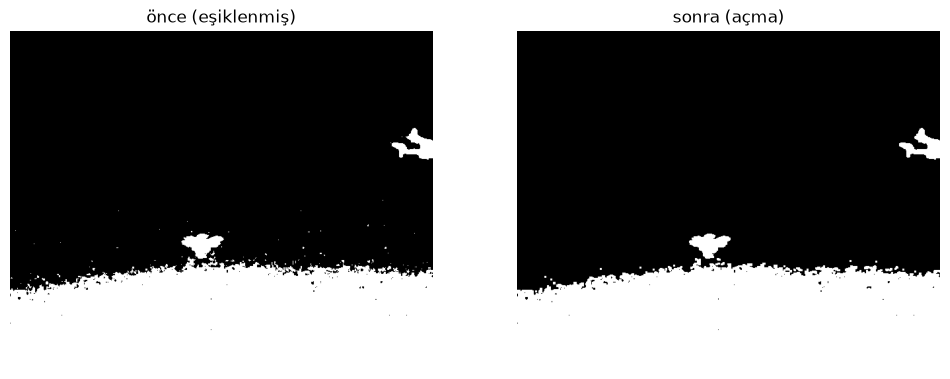

In [17]:
cekirdek = np.ones((3, 3), np.uint8)             # 3x3'lük tarama penceresi, içi hep 1

temiz = cv2.morphologyEx(                        # morfolojik işlem
    esik,                                        #   girdi: eşiklenmiş görüntü
    cv2.MORPH_OPEN,                              #   işlem türü: AÇMA
    cekirdek                                     #   pencere
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(esik, cmap="gray", vmin=0, vmax=255)
plt.title("önce (eşiklenmiş)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(temiz, cmap="gray", vmin=0, vmax=255)
plt.title("sonra (açma)")
plt.axis("off")

plt.show()

### 4.3 Kontur ve kutular
`findContours` beyaz lekelerin sınırlarını, `boundingRect` her lekeyi saran dikdörtgeni veriyor. Boyut süzgeci (`150 < alan < 20000`) gürültüyü ve devasa zemin lekesini eliyor.

**Sonuç: 21 leke bulundu, süzgeçten 2 tanesi geçti — iki İHA da yakalandı.** Eğitimsiz, 4 milisaniyede.

bulunan leke sayısı: 21
süzgeçten geçen: 2


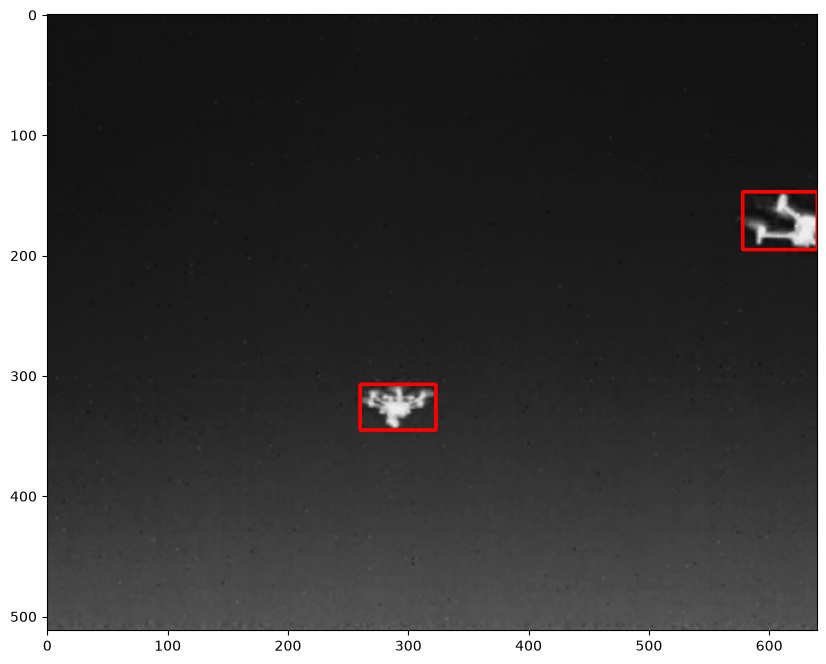

In [18]:
konturlar, hiyerarsi = cv2.findContours(         # beyaz lekelerin sınırlarını bul
    temiz,                                       #   girdi: temizlenmiş siyah-beyaz görüntü
    cv2.RETR_EXTERNAL,                           #   sadece dış sınırlar (iç delikleri atla)
    cv2.CHAIN_APPROX_SIMPLE                      #   sınırı az sayıda noktayla sakla
)

print("bulunan leke sayısı:", len(konturlar))

kutular = []                                     # boyut süzgecinden geçenler
for kontur in konturlar:                         # her leke için:
    x, y, w, h = cv2.boundingRect(kontur)        #   lekeyi saran dikdörtgen: sol üst + en/boy
    alan = w * h
    if 150 < alan < 20000:                       #   çok küçük ve çok büyük olanları ele
        kutular.append((x, y, x + w, y + h))     #   köşe biçiminde sakla

print("süzgeçten geçen:", len(kutular))

cizim = iha.copy()
for (x1, y1, x2, y2) in kutular:                 # her kutu için:
    cv2.rectangle(cizim, (x1, y1), (x2, y2), (0, 0, 255), 2)   # kırmızı kutu çiz

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(cizim, cv2.COLOR_BGR2RGB))
plt.show()

### 4.4 Aynı yöntem otoparkta
**Varsayım ters döndü:** Termal görüntüde güneşte ısınan asfalt, arabaların metal gövdesinden daha parlak. Otsu asfaltı beyaz saydı, arabalar koyu delikler olarak kaldı.

Otsu eşiği: 103.0
bulunan leke: 83 | süzgeçten geçen: 18


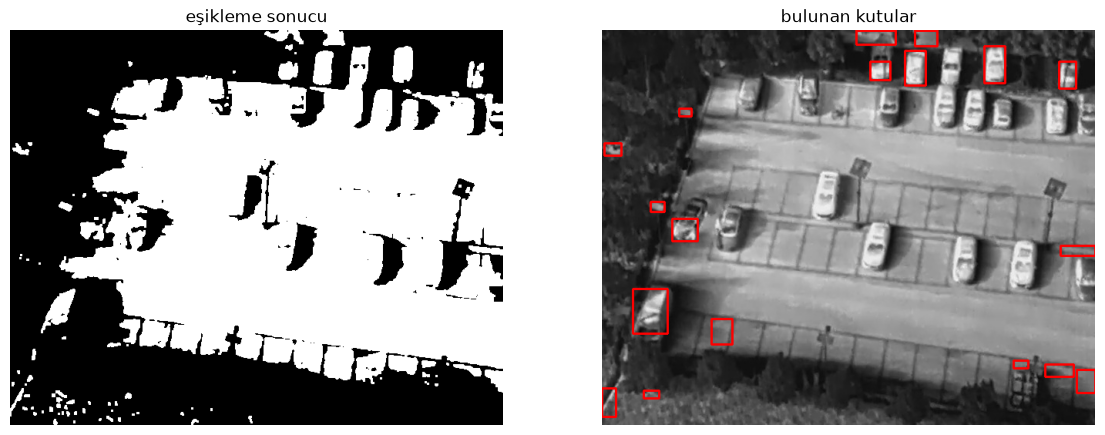

In [19]:
gri2 = cv2.cvtColor(otopark, cv2.COLOR_BGR2GRAY)                  # gri tonlama

esik_deger2, esik2 = cv2.threshold(gri2, 0, 255,
                                   cv2.THRESH_BINARY + cv2.THRESH_OTSU)   # eşikleme
print("Otsu eşiği:", esik_deger2)

temiz2 = cv2.morphologyEx(esik2, cv2.MORPH_OPEN, cekirdek)        # açma ile temizlik

konturlar2, _ = cv2.findContours(temiz2, cv2.RETR_EXTERNAL,
                                 cv2.CHAIN_APPROX_SIMPLE)          # lekelerin sınırları

kutular2 = []
for kontur in konturlar2:
    x, y, w, h = cv2.boundingRect(kontur)
    if 150 < w * h < 20000:
        kutular2.append((x, y, x + w, y + h))

print("bulunan leke:", len(konturlar2), "| süzgeçten geçen:", len(kutular2))

cizim2 = otopark.copy()
for (x1, y1, x2, y2) in kutular2:
    cv2.rectangle(cizim2, (x1, y1), (x2, y2), (0, 0, 255), 2)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(temiz2, cmap="gray", vmin=0, vmax=255)
plt.title("eşikleme sonucu")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(cizim2, cv2.COLOR_BGR2RGB))
plt.title("bulunan kutular")
plt.axis("off")
plt.show()

### 4.5 Ölçüm: kaç nesne yakalandı?
IoU ≥ 0.5 eşleşmesiyle sayım.

| | Klasik | YOLO |
|---|---|---|
| İHA fotoğrafı (2 nesne) | 2/2 | 2/2 |
| **Otopark (21 nesne)** | **3/21** | **21/21** |
| Sınıf ayrımı | yok, sadece "leke" | 7 sınıf |
| Hız | 4 ms | ~12 ms |
| Eğitim | gerekmez | 20 dk GPU + 3000 etiketli foto |
| Ayarlar | eşik, çekirdek, boyut sınırı elle | model kendi öğrenir |

In [20]:
def iou(a, b):                                    # 03'te yazdığın fonksiyonun aynısı
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    kx1, ky1 = max(ax1, bx1), max(ay1, by1)
    kx2, ky2 = min(ax2, bx2), min(ay2, by2)
    kesisim = max(0, kx2 - kx1) * max(0, ky2 - ky1)
    birlesim = (ax2-ax1)*(ay2-ay1) + (bx2-bx1)*(by2-by1) - kesisim
    return kesisim / birlesim


_, gercek_kutular = oku("02_hituav__0_100_50_0_08164__c5427da128")   # gerçek etiketler

eslesen = 0                                       # kaç gerçek nesne yakalandı
for (numara, gx1, gy1, gx2, gy2) in gercek_kutular:      # her gerçek nesne için:
    for (kx1, ky1, kx2, ky2) in kutular2:                #   bulunan her kutuyla karşılaştır
        if iou((gx1, gy1, gx2, gy2), (kx1, ky1, kx2, ky2)) >= 0.5:
            eslesen = eslesen + 1                        #   IoU 0.5'i geçen varsa yakalandı say
            break                                        #   bu nesne için yeterli, sıradakine geç

print(f"klasik yöntem: {len(gercek_kutular)} nesneden {eslesen} tanesini yakaladı")

klasik yöntem: 21 nesneden 3 tanesini yakaladı


## 5. Kestirme öğrenmenin kaynağını bulma
Dört kontrollü deney. `dene()` yalnızca yapıştırılan bölgedeki tahminleri yazdırıyor; `conf` güven eşiğini değiştirmemizi sağlıyor.

In [21]:
def dene(baslik, resim, bolge, conf=0.25):
    # resim: modele verilecek görüntü
    # bolge: yapıştırdığımız yer (x1, y1, x2, y2) — sadece oraya bakacağız
    # conf : güven eşiği. Varsayılan 0.25, altındaki tahminler elenir.

    sonuc = model(resim, verbose=False, conf=conf)[0]      # modeli çalıştır

    bx1, by1, bx2, by2 = bolge
    yakin = []                                             # yapıştırdığımız bölgedeki tahminler
    for kutu in sonuc.boxes:
        kx1, ky1, kx2, ky2 = kutu.xyxy[0].tolist()         # tahmin kutusunun köşeleri
        if kx1 < bx2 + 20 and kx2 > bx1 - 20 and ky1 < by2 + 20 and ky2 > by1 - 20:
            yakin.append((model.names[int(kutu.cls)], round(float(kutu.conf), 2)))

    print(baslik, "->", yakin if yakin else "HİÇBİR ŞEY")

### 5.1 Dört deneme
1. Asfalt, normal eşik (0.25)
2. Asfalt, çok düşük eşik (0.01) — model zayıf da olsa bir şey sezmiş mi?
3. Elle üretilmiş **düz koyu tuval** — gökyüzü fotoğrafı değil, sadece düz koyu bir zemin
4. Asfalt, İHA iki kat büyütülmüş — sorun boyut mu?

In [22]:
# 1) asfalt, normal eşik
kopya = otopark.copy()
kopya[400:400+ph, 300:300+pw] = parca
dene("1) asfalt, eşik 0.25    ", kopya, (300, 400, 300+pw, 400+ph))

# 2) aynı resim, çok düşük eşik — model zayıf da olsa bir şey görmüş mü?
dene("2) asfalt, eşik 0.01    ", kopya, (300, 400, 300+pw, 400+ph), conf=0.01)

# 3) yapay düz koyu arka plan — gökyüzü gibi ama gökyüzü değil
duz = np.full((512, 640, 3), 30, np.uint8)     # her pikseli 30 olan koyu gri tuval
duz[240:240+ph, 290:290+pw] = parca
dene("3) düz koyu tuval       ", duz, (290, 240, 290+pw, 240+ph))

# 4) asfalt ama İHA 2 kat büyütülmüş — sorun boyut mu?
buyuk = cv2.resize(parca, (pw*2, ph*2))        # parçayı iki katına ölçekle
kopya3 = otopark.copy()
kopya3[380:380+ph*2, 280:280+pw*2] = buyuk
dene("4) asfalt, 2 kat büyük  ", kopya3, (280, 380, 280+pw*2, 380+ph*2))

1) asfalt, eşik 0.25     -> HİÇBİR ŞEY
2) asfalt, eşik 0.01     -> [('car', 0.03)]
3) düz koyu tuval        -> [('drone', 0.91)]
4) asfalt, 2 kat büyük   -> HİÇBİR ŞEY


## Sonuç

### Deney sonuçları

| # | Deney | Sonuç | Çıkarım |
|---|---|---|---|
| 1 | Asfalt, eşik 0.25 | hiçbir şey | İHA tanınmıyor |
| 2 | Asfalt, eşik 0.01 | `car 0.03` | Model orada zayıf bir **araba** sezgisi taşıyor, İHA sezgisi hiç yok |
| 3 | Düz koyu tuval | **`drone 0.91`** | Aynı parça, aynı boyut → tanınıyor |
| 4 | Asfalt, 2 kat büyük | hiçbir şey | Sorun boyut değil |

### Model ne öğrenmiş?

> **"Düz ve koyu bir arka planda küçük parlak bir leke varsa, bu bir İHA'dır."**

Nesnenin şekli bu kuralın küçük bir parçası; arka plan baskın. 3. deney bunu kesinleştiriyor: gökyüzü fotoğrafı bile kullanılmadı, elle üretilen düz koyu bir tuval yetti.

2. deney ayrıca gösteriyor ki model yalnızca kutunun içine değil **fotoğrafın geneline** bakıyor: otopark bağlamında en zayıf tahmini bile araba yönünde.

### Sebebi ve çözümü

**Sebep veri:** Eğitimdeki bütün İHA'lar `uav2uav` kaynağından, hepsi gökyüzü arka planlı. Model "gökyüzü" ile "İHA"yı ayıramadı, ikisini tek kural olarak öğrendi. En kolay yolu buldu.

**Çözüm de veri:**
1. Farklı arka planlı (ağaç, bina, dağ) İHA görüntüleri toplamak
2. **Copy-paste augmentation**: bu deneyde elle yaptığımızı eğitim sırasında otomatik yapmak
3. Kaynakları karıştırmak: sınıfları farklı sahnelerde de göstermek

### Neden önemli?

Model kâğıt üstünde `drone: mAP50 0.94` alıyor. Ama ağaçların önünden geçen bir İHA'da muhtemelen çuvallayacak. Ölçüm iyi görünüyorken gerçek koşulda başarısız olan bir modelin nasıl tespit edileceğini gösteren bir örnek.